# PowerPlus — Final Pre-Decision-Tree Processing
## Standardization + EDA + Mean Imputation + Model-Ready Dataset

This notebook is the **next milestone after the three datasets have already been merged**.

### Input
The main input is:

`processed_data/powerplus_daily_merged.csv`

This file should contain the merged household-day data:

**Daily electricity + household metadata + daily weather + calendar + historical demand features.**

### This notebook does NOT train the Decision Tree.

It prepares and verifies the data before the model stage:

1. Load the merged PowerPlus dataset
2. Standardize all column names to `snake_case`
3. Standardize `city` and `house` identifiers
4. Perform EDA on every column
5. Calculate the average (mean) of every numerical column
6. Create a missing-value report
7. Apply **mean/average imputation** to appropriate numerical predictor columns
8. Handle categorical missing values
9. Protect the electricity target and historical lag/rolling features from inappropriate imputation
10. Validate the final dataset
11. Save the final dataset for the Decision Tree notebook

> **Important:** The target is `electricity_kwh`. We do not mean-impute the target.
> Lag/rolling features can be missing at the beginning of a household's history because previous observations do not exist. Those structural missing values are handled separately.


In [1]:
# 1. IMPORT LIBRARIES

from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# 2. FIND PROJECT ROOT AND INPUT/OUTPUT PATHS

def find_project_root():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path.cwd().parent.parent.parent
    ]
    for p in candidates:
        if (p / "processed_data").exists():
            return p
    return Path.cwd()

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "processed_data"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Preferred input from the previous notebook
MASTER_CANDIDATES = [
    PROCESSED_DIR / "powerplus_daily_merged.csv",
    PROCESSED_DIR / "master_electricity_dataset.csv",
    PROCESSED_DIR / "powerplus_model_data.csv",
]

MASTER_FILE = next((p for p in MASTER_CANDIDATES if p.exists()), None)

if MASTER_FILE is None:
    raise FileNotFoundError(
        "Could not find the merged PowerPlus CSV. Expected one of:\n" +
        "\n".join(str(p) for p in MASTER_CANDIDATES)
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT FILE:", MASTER_FILE)
print("PROCESSED_DIR:", PROCESSED_DIR)


PROJECT_ROOT: d:\Project-Electricity-Demand-Forecasting
INPUT FILE: d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_daily_merged.csv
PROCESSED_DIR: d:\Project-Electricity-Demand-Forecasting\processed_data


## 3. Why this notebook starts from `powerplus_daily_merged.csv`

The previous notebook already performed the main integration:

- minute-level electricity → daily kWh
- household metadata → household characteristics/appliances
- hourly weather → daily weather
- electricity + metadata + weather → merged household-day dataset
- calendar features
- lag features
- rolling historical demand features

Therefore, **do not merge the three raw datasets again here**.

This notebook starts from the merged dataset and prepares it for the Decision Tree.


In [3]:
# 4. LOAD THE MERGED DATASET

df = pd.read_csv(MASTER_FILE)

print("Dataset loaded.")
print("Rows:", len(df))
print("Columns:", len(df.columns))
display(df.head())

print("\nOriginal column names:")
print(df.columns.tolist())


Dataset loaded.
Rows: 20951
Columns: 91


,city,house,date,electricity_kwh,readings,avg_power_kw,max_power_kw,min_power_kw,expected_readings,coverage_pct,low_coverage_flag,House,City,Owner/Rented,No. of people (Temp+Perm),No. of Permanent residents,No. of Children (0-13),No. of Adults (14-60),No. of Seniors (above 60),No. of temporary residents,Property Area (Marla),Covered Area,No of Floors,Floor of Residency,Build year of house,Wapda Connection type,Average Ceiling Height ft,Ceiling Type,Roof Type,Flooring Type,Interior Wall,Exterior Wall,No. of rooms,Room Dimensions,Kitchen,Number of Washrooms,Number of Stores,Doors Type,Air Conditioners,Air Coolers,Refrigerators,Washing Machines,LED Bulbs,Tube Lights,Celling Fans,Wall Fans,Stand Fans,Water Dispensers,Water Pumps,Electric Cooker,Electric heaters,Electric Irons,Sewing Machine,Microwave Ovens,Geysers,UPS,Other Electronic Devices,temperature_mean,humidity_mean,dew_mean,wind_speed_mean,wind_direction_mean,pressure_mean,solar_radiation_mean,temperature_max,humidity_max,wind_speed_max,solar_radiation_max,uv_index_max,precipitation_sum,solar_energy_sum,year,month,day,day_of_week,week_of_year,day_of_year,is_weekend,season,lag_1_day_kwh,lag_2_day_kwh,lag_3_day_kwh,lag_7_day_kwh,lag_14_day_kwh,lag_30_day_kwh,rolling_3_day_avg_kwh,rolling_7_day_avg_kwh,rolling_14_day_avg_kwh,rolling_30_day_avg_kwh,house_age,total_appliance_count
0,Islamabad,House#41,2023-11-01,0.010500,1,0.63,0.63,0.63,1440,0.069444,True,House#41,Islamabad,Owner,6.0,6.0,2.0,4.0,0.0,0.0,4.5,4.5,2,Whole,2014.0,1 phase,12.0,Cemented,Cemented,Marble,Painted,Painted,5.0,12*13,1.0,4.0,0.0,Wooden,2.0,0,1.0,1,20.0,0,5.0,2.0,0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,18.9,84.87,16.3,6.5,52.0,1018.0,0.0,18.9,84.87,6.5,0.0,0,0.0,0.0,2023,11,1,2,44,305,0,Autumn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,35.0
1,Islamabad,House#41,2023-11-02,0.008500,1,0.51,0.51,0.51,1440,0.069444,True,House#41,Islamabad,Owner,6.0,6.0,2.0,4.0,0.0,0.0,4.5,4.5,2,Whole,2014.0,1 phase,12.0,Cemented,Cemented,Marble,Painted,Painted,5.0,12*13,1.0,4.0,0.0,Wooden,2.0,0,1.0,1,20.0,0,5.0,2.0,0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,18.2,81.07,14.9,4.7,20.4,1017.0,0.0,18.2,81.07,4.7,0.0,0,0.0,0.0,2023,11,2,3,44,306,0,Autumn,0.010500,NaN,NaN,NaN,NaN,NaN,0.010500,0.010500,0.010500,0.010500,9.0,35.0
2,Islamabad,House#41,2023-11-03,0.010500,1,0.63,0.63,0.63,1440,0.069444,True,House#41,Islamabad,Owner,6.0,6.0,2.0,4.0,0.0,0.0,4.5,4.5,2,Whole,2014.0,1 phase,12.0,Cemented,Cemented,Marble,Painted,Painted,5.0,12*13,1.0,4.0,0.0,Wooden,2.0,0,1.0,1,20.0,0,5.0,2.0,0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,18.0,78.98,14.3,7.6,36.8,1015.0,0.0,18.0,78.98,7.6,0.0,0,0.0,0.0,2023,11,3,4,44,307,0,Autumn,0.008500,0.0105,NaN,NaN,NaN,NaN,0.009500,0.009500,0.009500,0.009500,9.0,35.0
3,Islamabad,House#41,2023-11-04,0.010167,1,0.61,0.61,0.61,1440,0.069444,True,House#41,Islamabad,Owner,6.0,6.0,2.0,4.0,0.0,0.0,4.5,4.5,2,Whole,2014.0,1 phase,12.0,Cemented,Cemented,Marble,Painted,Painted,5.0,12*13,1.0,4.0,0.0,Wooden,2.0,0,1.0,1,20.0,0,5.0,2.0,0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,17.9,74.48,13.3,4.3,48.0,1014.0,0.0,17.9,74.48,4.3,0.0,0,0.0,0.0,2023,11,4,5,44,308,1,Autumn,0.010500,0.0085,0.0105,NaN,NaN,NaN,0.009833,0.009833,0.009833,0.009833,9.0,35.0
4,Islamabad,House#41,2023-11-05,0.008333,1,0.50,0.50,0.50,1440,0.069444,True,House#41,Islamabad,Owner,6.0,6.0,2.0,4.0,0.0,0.0,4.5,4.5,2,Whole,2014.0,1 phase,12.0,Cemented,Cemented,Marble,Painted,Painted,5.0,12*13,1.0,4.0,0.0,Wooden,2.0,0,1.0,1,20.0,0,5.0,2.0,0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,17.1,66.89,10.9,5.0,32.4,1015.0,0.0,17.1,66.89,5.0,0.0,0,0.0,0.0,2023,11,5,6,44,309,1,Autumn,0.010167,0.0105,0.0085,NaN,NaN,NaN,0.009722,0.009917,0.009917,0.009917,9.0,35.0



Original column names:
['city', 'house', 'date', 'electricity_kwh', 'readings', 'avg_power_kw', 'max_power_kw', 'min_power_kw', 'expected_readings', 'coverage_pct', 'low_coverage_flag', 'House', 'City', 'Owner/Rented', 'No. of people (Temp+Perm)', 'No. of Permanent residents', 'No. of Children (0-13)', 'No. of Adults (14-60)', 'No. of Seniors (above 60)', 'No. of temporary residents', 'Property Area (Marla)', 'Covered Area', 'No of Floors', 'Floor of Residency', 'Build year of house', 'Wapda Connection type', 'Average Ceiling Height ft', 'Ceiling Type', 'Roof Type', 'Flooring Type', 'Interior Wall', 'Exterior Wall', 'No. of rooms', 'Room Dimensions', 'Kitchen', 'Number of Washrooms', 'Number of Stores', 'Doors Type', 'Air Conditioners', 'Air Coolers', 'Refrigerators', 'Washing Machines', 'LED Bulbs', 'Tube Lights', 'Celling Fans', 'Wall Fans', 'Stand Fans', 'Water Dispensers', 'Water Pumps', 'Electric Cooker', 'Electric heaters', 'Electric Irons', 'Sewing Machine', 'Microwave Ovens', 

# 5. STANDARDIZE ALL COLUMN NAMES

All columns are converted to a consistent `snake_case` format.

Examples:

- `No. of Permanent residents` → `no_of_permanent_residents`
- `Property Area (Marla)` → `property_area_marla`
- `Air Conditioners` → `air_conditioners`
- `Build year of house` → `build_year_of_house`
- `Wapda Connection type` → `wapda_connection_type`

This makes the later Python/Decision Tree code much easier to maintain.


In [4]:
# 5. STANDARDIZE COLUMN NAMES TO SNAKE_CASE

def normalize_column_name(col):
    col = str(col).strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

original_columns = df.columns.tolist()
df.columns = [normalize_column_name(c) for c in df.columns]

# Remove accidental duplicate column names safely
seen = {}
new_columns = []
for col in df.columns:
    if col not in seen:
        seen[col] = 0
        new_columns.append(col)
    else:
        seen[col] += 1
        new_columns.append(f"{col}_{seen[col]}")
df.columns = new_columns

print("Standardized column names:")
print(df.columns.tolist())


Standardized column names:
['city', 'house', 'date', 'electricity_kwh', 'readings', 'avg_power_kw', 'max_power_kw', 'min_power_kw', 'expected_readings', 'coverage_pct', 'low_coverage_flag', 'house_1', 'city_1', 'owner_rented', 'no_of_people_temp_perm', 'no_of_permanent_residents', 'no_of_children_0_13', 'no_of_adults_14_60', 'no_of_seniors_above_60', 'no_of_temporary_residents', 'property_area_marla', 'covered_area', 'no_of_floors', 'floor_of_residency', 'build_year_of_house', 'wapda_connection_type', 'average_ceiling_height_ft', 'ceiling_type', 'roof_type', 'flooring_type', 'interior_wall', 'exterior_wall', 'no_of_rooms', 'room_dimensions', 'kitchen', 'number_of_washrooms', 'number_of_stores', 'doors_type', 'air_conditioners', 'air_coolers', 'refrigerators', 'washing_machines', 'led_bulbs', 'tube_lights', 'celling_fans', 'wall_fans', 'stand_fans', 'water_dispensers', 'water_pumps', 'electric_cooker', 'electric_heaters', 'electric_irons', 'sewing_machine', 'microwave_ovens', 'geysers',

In [5]:
# 6. STANDARDIZE CORE KEY COLUMNS

# Common possible names from earlier processing
rename_map = {}

def first_existing(candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

date_col = first_existing(["date", "datetime", "timestamp"])
city_col = first_existing(["city", "location", "city_name"])
house_col = first_existing(["house", "house_name", "house_number"])
target_col = first_existing([
    "electricity_kwh",
    "electricity_consumption_kwh",
    "daily_consumption_kwh",
    "usage_kwh"
])

if date_col is None:
    raise ValueError("Date column not found.")
if city_col is None:
    raise ValueError("City column not found.")
if house_col is None:
    raise ValueError("House column not found.")
if target_col is None:
    raise ValueError("Electricity target column not found.")

rename_map[date_col] = "date"
rename_map[city_col] = "city"
rename_map[house_col] = "house"
rename_map[target_col] = "electricity_kwh"

df = df.rename(columns=rename_map)

df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Core columns:")
print([c for c in ["date", "city", "house", "electricity_kwh"] if c in df.columns])


Core columns:
['date', 'city', 'house', 'electricity_kwh']


In [6]:
# 7. STANDARDIZE CITY NAMES

# Strip spaces and normalize capitalization.
df["city"] = (
    df["city"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Known PowerPlus cities
city_map = {
    "islamabad": "Islamabad",
    "karachi": "Karachi",
    "lahore": "Lahore",
    "multan": "Multan",
    "peshawar": "Peshawar",
    "skardu": "Skardu",
}

df["city"] = df["city"].str.lower().map(
    lambda x: city_map.get(x, x.title() if pd.notna(x) else x)
)

print("Unique standardized cities:")
print(sorted(df["city"].dropna().unique().tolist()))


Unique standardized cities:
['Islamabad', 'Karachi', 'Lahore', 'Multan', 'Peshawar', 'Skardu']


In [7]:
# 8. STANDARDIZE HOUSE IDENTIFIERS

def standardize_house(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    match = re.search(r"house\s*#?\s*(\d+)", value, flags=re.I)
    if match:
        return f"House#{int(match.group(1))}"
    return value

df["house"] = df["house"].apply(standardize_house)

print("Example standardized houses:")
display(pd.DataFrame({"house": df["house"].dropna().unique()[:30]}))


Example standardized houses:


,house
0,House#41
1,House#42
2,House#43
3,House#44
4,House#45
5,House#46
6,House#47
7,House#48
8,House#49
9,House#50


In [8]:
# 9. BASIC TYPE CLEANING

# Convert common invalid tokens to NaN
invalid_tokens = [
    "#REF!", "#DIV/0!", "#VALUE!", "#N/A",
    "N/A", "NA", "na", "null", "NULL",
    "None", "none", "", " "
]

df = df.replace(invalid_tokens, np.nan)

# Remove duplicate household-day records
before = len(df)
df = df.drop_duplicates(subset=["city", "house", "date"], keep="first").copy()

print("Duplicate household-day rows removed:", before - len(df))

# Sort chronologically
df = df.sort_values(["city", "house", "date"]).reset_index(drop=True)

print("Shape after basic cleaning:", df.shape)


Duplicate household-day rows removed: 0
Shape after basic cleaning: (20951, 91)


# 10. EDA — DATASET OVERVIEW

Before imputation, we inspect the data exactly as it currently exists.

The EDA includes:

- shape
- data types
- missing values
- unique values
- mean/average for every numerical column
- median
- minimum
- maximum
- standard deviation
- categorical summaries

### Important
A mathematical average is meaningful for **numerical columns**. For text/categorical columns such as city, roof type, or owner/rented, we instead report unique values and the most frequent category.


In [9]:
# 11. EDA — DATASET SHAPE AND TYPES

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

dtype_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "unique_values": [df[c].nunique(dropna=True) for c in df.columns],
    "missing_count": [df[c].isna().sum() for c in df.columns],
})

dtype_summary["missing_percent"] = (
    dtype_summary["missing_count"] / len(df) * 100
)

display(dtype_summary)


Rows: 20951
Columns: 91


,column,dtype,unique_values,missing_count,missing_percent
0,city,object,6,0,0.000000
1,house,object,59,0,0.000000
2,date,datetime64[ns],501,0,0.000000
3,electricity_kwh,float64,18213,0,0.000000
4,readings,int64,301,0,0.000000
5,avg_power_kw,float64,18211,0,0.000000
6,max_power_kw,float64,18089,0,0.000000
7,min_power_kw,float64,17282,0,0.000000
8,expected_readings,int64,1,0,0.000000
9,coverage_pct,float64,301,0,0.000000


In [10]:
# 12. EDA — NUMERIC CONVERSION CHECK

# Convert columns that are genuinely numeric-looking.
# Date/city/house remain their proper types.

protected_text = {"date", "city", "house"}

for col in df.columns:
    if col not in protected_text:
        # Try numeric conversion only when most non-null values can be interpreted as numbers.
        original_non_null = df[col].notna().sum()
        if original_non_null == 0:
            continue

        converted = pd.to_numeric(df[col], errors="coerce")
        conversion_rate = converted.notna().sum() / original_non_null

        if conversion_rate >= 0.80:
            df[col] = converted

print("Numeric columns detected:")
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(numeric_cols)


Numeric columns detected:
['electricity_kwh', 'readings', 'avg_power_kw', 'max_power_kw', 'min_power_kw', 'expected_readings', 'coverage_pct', 'no_of_people_temp_perm', 'no_of_permanent_residents', 'no_of_children_0_13', 'no_of_adults_14_60', 'no_of_seniors_above_60', 'no_of_temporary_residents', 'property_area_marla', 'covered_area', 'no_of_floors', 'build_year_of_house', 'average_ceiling_height_ft', 'no_of_rooms', 'kitchen', 'number_of_washrooms', 'number_of_stores', 'air_conditioners', 'air_coolers', 'refrigerators', 'washing_machines', 'led_bulbs', 'tube_lights', 'celling_fans', 'wall_fans', 'stand_fans', 'water_dispensers', 'water_pumps', 'electric_cooker', 'electric_heaters', 'electric_irons', 'sewing_machine', 'microwave_ovens', 'geysers', 'ups', 'other_electronic_devices', 'temperature_mean', 'humidity_mean', 'dew_mean', 'wind_speed_mean', 'wind_direction_mean', 'pressure_mean', 'solar_radiation_mean', 'temperature_max', 'humidity_max', 'wind_speed_max', 'solar_radiation_max', 

In [11]:
# 13. EDA — AVERAGE (MEAN) OF EVERY NUMERICAL COLUMN

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

numeric_eda = pd.DataFrame({
    "column": numeric_cols,
    "count": [df[c].count() for c in numeric_cols],
    "missing_count": [df[c].isna().sum() for c in numeric_cols],
    "missing_percent": [
        df[c].isna().mean() * 100 for c in numeric_cols
    ],
    "average_mean": [df[c].mean() for c in numeric_cols],
    "median": [df[c].median() for c in numeric_cols],
    "minimum": [df[c].min() for c in numeric_cols],
    "maximum": [df[c].max() for c in numeric_cols],
    "std_dev": [df[c].std() for c in numeric_cols],
})

numeric_eda = numeric_eda.sort_values(
    ["missing_percent", "column"],
    ascending=[False, True]
).reset_index(drop=True)

print("Average/mean calculated for every numerical column.")
display(numeric_eda)


Average/mean calculated for every numerical column.


,column,count,missing_count,missing_percent,average_mean,median,minimum,maximum,std_dev
0,lag_30_day_kwh,19181,1770,8.448284,1.391229,0.008219,0.000000,81.780713,6.797216
1,number_of_stores,19858,1093,5.216935,0.972354,1.000000,0.000000,2.000000,0.628983
2,lag_14_day_kwh,20125,826,3.942533,1.381569,0.008344,0.000000,81.780713,6.729796
3,kitchen,20221,730,3.484321,1.176351,1.000000,1.000000,2.000000,0.381128
4,led_bulbs,20221,730,3.484321,45.976213,30.000000,7.000000,160.000000,40.060372
5,other_electronic_devices,20248,703,3.355448,0.060302,0.000000,0.000000,3.000000,0.421045
6,lag_7_day_kwh,20538,413,1.971266,1.372081,0.008337,0.000000,81.780713,6.688350
7,air_conditioners,20586,365,1.742160,3.106820,3.000000,0.000000,12.000000,2.385224
8,average_ceiling_height_ft,20586,365,1.742160,10.601137,10.000000,8.000000,15.000000,1.339574
9,build_year_of_house,20586,365,1.742160,2007.644564,2011.000000,1960.000000,2022.000000,11.075948


In [12]:
# 14. SAVE NUMERICAL EDA SUMMARY

eda_numeric_file = PROCESSED_DIR / "powerplus_eda_numeric_summary.csv"
numeric_eda.to_csv(eda_numeric_file, index=False)

print("Saved:", eda_numeric_file)


Saved: d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_eda_numeric_summary.csv


In [13]:
# 15. EDA — CATEGORICAL COLUMN SUMMARY

categorical_cols = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

categorical_rows = []

for col in categorical_cols:
    mode_values = df[col].mode(dropna=True)
    mode_value = mode_values.iloc[0] if len(mode_values) else np.nan

    categorical_rows.append({
        "column": col,
        "missing_count": df[col].isna().sum(),
        "missing_percent": df[col].isna().mean() * 100,
        "unique_count": df[col].nunique(dropna=True),
        "most_frequent_value": mode_value
    })

categorical_eda = pd.DataFrame(categorical_rows).sort_values(
    "missing_percent", ascending=False
)

display(categorical_eda)


,column,missing_count,missing_percent,unique_count,most_frequent_value
6,wapda_connection_type,365,1.74216,4,1 phase
7,ceiling_type,365,1.74216,7,Cemented
12,room_dimensions,365,1.74216,28,12*14
0,city,0,0.00000,6,Karachi
1,house,0,0.00000,59,House#51
2,house_1,0,0.00000,59,House#51
3,city_1,0,0.00000,6,Karachi
4,owner_rented,0,0.00000,3,Owner
5,floor_of_residency,0,0.00000,6,Whole
8,roof_type,0,0.00000,6,Cemented


In [14]:
# 16. COMPLETE MISSING-VALUE REPORT BEFORE IMPUTATION

missing_before = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count_before": df.isna().sum().values,
})

missing_before["missing_percent_before"] = (
    missing_before["missing_count_before"] / len(df) * 100
)

missing_before = missing_before.sort_values(
    "missing_count_before", ascending=False
).reset_index(drop=True)

display(missing_before)


,column,dtype,missing_count_before,missing_percent_before
0,lag_30_day_kwh,float64,1770,8.448284
1,number_of_stores,float64,1093,5.216935
2,lag_14_day_kwh,float64,826,3.942533
3,kitchen,float64,730,3.484321
4,led_bulbs,float64,730,3.484321
5,other_electronic_devices,float64,703,3.355448
6,lag_7_day_kwh,float64,413,1.971266
7,wall_fans,float64,365,1.742160
8,ceiling_type,object,365,1.742160
9,ups,float64,365,1.742160


# 17. MEAN / AVERAGE IMPUTATION POLICY

The supervisor's average-imputation requirement is implemented here.

### Numerical predictor columns
For missing numerical predictor values:

`missing value → column mean`

Example:

`28, 30, NaN, 32, 29`

Mean = `29.75`

The missing value becomes `29.75`.

### Columns NOT mean-imputed

**1. `electricity_kwh`**
- This is the prediction target.
- We do not invent target values using an average.

**2. Lag and rolling historical-demand features**
- These can be missing at the beginning of each household's time series because the previous observation does not exist.
- They are structural forecasting features, not ordinary missing data.
- We keep them missing here and remove insufficient-history rows when creating the final model dataset.

### Categorical columns
Text values cannot be averaged, so missing categorical values are filled with:

`Unknown`

This keeps the row available for the Decision Tree's later encoding step.


In [15]:
# 18. IDENTIFY COLUMNS FOR MEAN IMPUTATION

TARGET = "electricity_kwh"

# Historical features that should not be mean-imputed
historical_columns = [
    c for c in df.columns
    if (
        c.startswith("lag_")
        or c.startswith("rolling_")
    )
]

# Numeric columns suitable for ordinary mean imputation
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

mean_imputation_cols = [
    c for c in numeric_cols
    if c != TARGET and c not in historical_columns
]

print("Target protected from imputation:")
print(TARGET)

print("\nHistorical lag/rolling columns protected from mean imputation:")
print(historical_columns)

print("\nNumerical columns receiving mean imputation:")
print(mean_imputation_cols)


Target protected from imputation:
electricity_kwh

Historical lag/rolling columns protected from mean imputation:
['lag_1_day_kwh', 'lag_2_day_kwh', 'lag_3_day_kwh', 'lag_7_day_kwh', 'lag_14_day_kwh', 'lag_30_day_kwh', 'rolling_3_day_avg_kwh', 'rolling_7_day_avg_kwh', 'rolling_14_day_avg_kwh', 'rolling_30_day_avg_kwh']

Numerical columns receiving mean imputation:
['readings', 'avg_power_kw', 'max_power_kw', 'min_power_kw', 'expected_readings', 'coverage_pct', 'no_of_people_temp_perm', 'no_of_permanent_residents', 'no_of_children_0_13', 'no_of_adults_14_60', 'no_of_seniors_above_60', 'no_of_temporary_residents', 'property_area_marla', 'covered_area', 'no_of_floors', 'build_year_of_house', 'average_ceiling_height_ft', 'no_of_rooms', 'kitchen', 'number_of_washrooms', 'number_of_stores', 'air_conditioners', 'air_coolers', 'refrigerators', 'washing_machines', 'led_bulbs', 'tube_lights', 'celling_fans', 'wall_fans', 'stand_fans', 'water_dispensers', 'water_pumps', 'electric_cooker', 'electr

In [16]:
# 19. APPLY COLUMN-WISE MEAN IMPUTATION

imputation_records = []

for col in mean_imputation_cols:
    missing_before_col = int(df[col].isna().sum())
    mean_value = df[col].mean()

    # Only fill if a valid mean exists.
    if pd.notna(mean_value):
        df[col] = df[col].fillna(mean_value)

    missing_after_col = int(df[col].isna().sum())

    imputation_records.append({
        "column": col,
        "method": "mean",
        "mean_used": mean_value,
        "missing_before": missing_before_col,
        "values_imputed": missing_before_col - missing_after_col,
        "missing_after": missing_after_col
    })

imputation_report = pd.DataFrame(imputation_records)

display(imputation_report)


,column,method,mean_used,missing_before,values_imputed,missing_after
0,readings,mean,128.835616,0,0,0
1,avg_power_kw,mean,0.836282,0,0,0
2,max_power_kw,mean,1.000189,0,0,0
3,min_power_kw,mean,0.783023,0,0,0
4,expected_readings,mean,1440.000000,0,0,0
5,coverage_pct,mean,8.946918,0,0,0
6,no_of_people_temp_perm,mean,6.201108,365,365,0
7,no_of_permanent_residents,mean,5.606529,365,365,0
8,no_of_children_0_13,mean,1.349024,365,365,0
9,no_of_adults_14_60,mean,3.773827,365,365,0


In [17]:
# 20. HANDLE MISSING CATEGORICAL VALUES

categorical_cols = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

categorical_imputation_records = []

for col in categorical_cols:
    if col in ["city", "house"]:
        # Keys should not be fabricated.
        continue

    missing_before_col = int(df[col].isna().sum())

    if missing_before_col > 0:
        df[col] = df[col].fillna("Unknown")

    categorical_imputation_records.append({
        "column": col,
        "method": "Unknown",
        "missing_before": missing_before_col,
        "missing_after": int(df[col].isna().sum())
    })

categorical_imputation_report = pd.DataFrame(categorical_imputation_records)

print("Categorical missing values handled with 'Unknown'.")
display(categorical_imputation_report)


Categorical missing values handled with 'Unknown'.


,column,method,missing_before,missing_after
0,house_1,Unknown,0,0
1,city_1,Unknown,0,0
2,owner_rented,Unknown,0,0
3,floor_of_residency,Unknown,0,0
4,wapda_connection_type,Unknown,365,0
5,ceiling_type,Unknown,365,0
6,roof_type,Unknown,0,0
7,flooring_type,Unknown,0,0
8,interior_wall,Unknown,0,0
9,exterior_wall,Unknown,0,0


In [18]:
# 21. TARGET AND KEY VALIDATION

# Date, city and house are required identifiers.
df = df.dropna(subset=["date", "city", "house"]).copy()

# Never fabricate the prediction target.
target_missing = df["electricity_kwh"].isna().sum()

print("Missing target values:", target_missing)

if target_missing > 0:
    print("Rows with missing target will be removed before model training.")
    df = df.dropna(subset=["electricity_kwh"]).copy()

print("Rows after target/key validation:", len(df))


Missing target values: 0
Rows after target/key validation: 20951


# 22. HANDLE HISTORICAL LAG / ROLLING FEATURES

The previous feature-engineering stage created features such as:

- `lag_1_day_kwh`
- `lag_7_day_kwh`
- `lag_30_day_kwh`
- `rolling_7_day_avg_kwh`
- `rolling_30_day_avg_kwh`

The first days of a household's history naturally have no previous observations.

We therefore **do not replace these with the overall average**.

For the final Decision Tree dataset, we require the minimum historical features needed for forecasting:

- lag 1 day
- lag 7 days
- lag 30 days

Rows without these historical observations are removed.


In [19]:
# 23. CREATE MODEL-READY DATASET

required_history = [
    c for c in [
        "lag_1_day_kwh",
        "lag_7_day_kwh",
        "lag_30_day_kwh"
    ]
    if c in df.columns
]

model_data = df.copy()

if required_history:
    before_history = len(model_data)

    model_data = model_data.dropna(
        subset=required_history
    ).copy()

    print("Rows removed because required historical features were unavailable:",
          before_history - len(model_data))

model_data = model_data.sort_values(
    ["city", "house", "date"]
).reset_index(drop=True)

print("Final pre-Decision-Tree dataset shape:", model_data.shape)
display(model_data.head())


Rows removed because required historical features were unavailable: 1770
Final pre-Decision-Tree dataset shape: (19181, 91)


,city,house,date,electricity_kwh,readings,avg_power_kw,max_power_kw,min_power_kw,expected_readings,coverage_pct,low_coverage_flag,house_1,city_1,owner_rented,no_of_people_temp_perm,no_of_permanent_residents,no_of_children_0_13,no_of_adults_14_60,no_of_seniors_above_60,no_of_temporary_residents,property_area_marla,covered_area,no_of_floors,floor_of_residency,build_year_of_house,wapda_connection_type,average_ceiling_height_ft,ceiling_type,roof_type,flooring_type,interior_wall,exterior_wall,no_of_rooms,room_dimensions,kitchen,number_of_washrooms,number_of_stores,doors_type,air_conditioners,air_coolers,refrigerators,washing_machines,led_bulbs,tube_lights,celling_fans,wall_fans,stand_fans,water_dispensers,water_pumps,electric_cooker,electric_heaters,electric_irons,sewing_machine,microwave_ovens,geysers,ups,other_electronic_devices,temperature_mean,humidity_mean,dew_mean,wind_speed_mean,wind_direction_mean,pressure_mean,solar_radiation_mean,temperature_max,humidity_max,wind_speed_max,solar_radiation_max,uv_index_max,precipitation_sum,solar_energy_sum,year,month,day,day_of_week,week_of_year,day_of_year,is_weekend,season,lag_1_day_kwh,lag_2_day_kwh,lag_3_day_kwh,lag_7_day_kwh,lag_14_day_kwh,lag_30_day_kwh,rolling_3_day_avg_kwh,rolling_7_day_avg_kwh,rolling_14_day_avg_kwh,rolling_30_day_avg_kwh,house_age,total_appliance_count
0,Islamabad,House#41,2023-12-01,0.020667,1,1.24,1.24,1.24,1440,0.069444,True,House#41,Islamabad,Owner,6.0,6.0,2.0,4.0,0.0,0.0,4.5,4.5,2,Whole,2014.0,1 phase,12.0,Cemented,Cemented,Marble,Painted,Painted,5.0,12*13,1.0,4.0,0.0,Wooden,2.0,0,1.0,1,20.0,0,5.0,2.0,0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,13.1,85.93,10.8,6.8,36.9,1021.0,0.0,13.1,85.93,6.8,0.0,0,0.0,0.0,2023,12,1,4,48,335,0,Winter,0.015667,0.016000,0.015500,0.025000,0.0000,0.010500,0.015722,0.017452,0.011143,0.010961,9.0,35.0
1,Islamabad,House#41,2023-12-02,0.020000,1,1.20,1.20,1.20,1440,0.069444,True,House#41,Islamabad,Owner,6.0,6.0,2.0,4.0,0.0,0.0,4.5,4.5,2,Whole,2014.0,1 phase,12.0,Cemented,Cemented,Marble,Painted,Painted,5.0,12*13,1.0,4.0,0.0,Wooden,2.0,0,1.0,1,20.0,0,5.0,2.0,0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,13.7,83.19,10.9,6.8,31.8,1019.0,0.0,13.7,83.19,6.8,0.0,0,0.0,0.0,2023,12,2,5,48,336,1,Winter,0.020667,0.015667,0.016000,0.020000,0.0100,0.008500,0.017444,0.016833,0.012619,0.011300,9.0,35.0
2,Islamabad,House#41,2023-12-03,0.000000,1,0.00,0.00,0.00,1440,0.069444,True,House#41,Islamabad,Owner,6.0,6.0,2.0,4.0,0.0,0.0,4.5,4.5,2,Whole,2014.0,1 phase,12.0,Cemented,Cemented,Marble,Painted,Painted,5.0,12*13,1.0,4.0,0.0,Wooden,2.0,0,1.0,1,20.0,0,5.0,2.0,0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,13.1,83.12,10.3,7.2,39.3,1019.0,0.0,13.1,83.12,7.2,0.0,0,0.0,0.0,2023,12,3,6,48,337,1,Winter,0.020000,0.020667,0.015667,0.015167,0.0000,0.010500,0.018778,0.016833,0.013333,0.011683,9.0,35.0
3,Islamabad,House#41,2023-12-04,0.000000,1,0.00,0.00,0.00,1440,0.069444,True,House#41,Islamabad,Owner,6.0,6.0,2.0,4.0,0.0,0.0,4.5,4.5,2,Whole,2014.0,1 phase,12.0,Cemented,Cemented,Marble,Painted,Painted,5.0,12*13,1.0,4.0,0.0,Wooden,2.0,0,1.0,1,20.0,0,5.0,2.0,0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,12.6,79.78,9.2,5.0,18.8,1018.0,0.0,12.6,79.78,5.0,0.0,0,0.0,0.0,2023,12,4,0,49,338,0,Winter,0.000000,0.020000,0.020667,0.014833,0.0000,0.010167,0.013556,0.014667,0.013333,0.011333,9.0,35.0
4,Islamabad,House#41,2023-12-05,0.018833,1,1.13,1.13,1.13,1440,0.069444,True,House#41,Islamabad,Owner,6.0,6.0,2.0,4.0,0.0,0.0,4.5,4.5,2,Whole,2014.0,1 phase,12.0,Cemented,Cemented,Marble,Painted,Painted,5.0,12*13,1.0,4.0,0.0,Wooden,2.0,0,1.0,1,20.0,0,5.0,2.0,0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,11.7,81.28,8.6,4.3,48.6,1017.0,0.0,11.7,81.28,4.3,0.0,0,0.0,0.0,2023,12,5,1,49,339,0,Winter,0.000000,0.000000,0.020000,0.015500,0.0115,0.008333,0.006667,0.012548,0.013333,0.010994,9.0,35.0


In [20]:
# 24. FINAL MISSING-VALUE CHECK AFTER IMPUTATION

missing_after = pd.DataFrame({
    "column": model_data.columns,
    "dtype": model_data.dtypes.astype(str).values,
    "missing_count_after": model_data.isna().sum().values,
})

missing_after["missing_percent_after"] = (
    missing_after["missing_count_after"] / len(model_data) * 100
)

missing_after = missing_after.sort_values(
    "missing_count_after", ascending=False
).reset_index(drop=True)

display(missing_after)


,column,dtype,missing_count_after,missing_percent_after
0,city,object,0,0.0
1,uv_index_max,int64,0,0.0
2,wind_speed_max,float64,0,0.0
3,humidity_max,float64,0,0.0
4,temperature_max,float64,0,0.0
5,solar_radiation_mean,float64,0,0.0
6,pressure_mean,float64,0,0.0
7,wind_direction_mean,float64,0,0.0
8,wind_speed_mean,float64,0,0.0
9,dew_mean,float64,0,0.0


In [21]:
# 25. BEFORE vs AFTER MISSING-VALUE REPORT

before_lookup = missing_before.set_index("column")
after_lookup = missing_after.set_index("column")

comparison = pd.DataFrame(index=model_data.columns)
comparison["missing_before"] = [
    int(before_lookup.loc[c, "missing_count_before"])
    if c in before_lookup.index else 0
    for c in model_data.columns
]
comparison["missing_after"] = [
    int(after_lookup.loc[c, "missing_count_after"])
    if c in after_lookup.index else 0
    for c in model_data.columns
]
comparison["values_filled_or_removed"] = (
    comparison["missing_before"] - comparison["missing_after"]
)

comparison = comparison.sort_values(
    "missing_before", ascending=False
)

display(comparison)


,missing_before,missing_after,values_filled_or_removed
lag_30_day_kwh,1770,0,1770
number_of_stores,1093,0,1093
lag_14_day_kwh,826,0,826
kitchen,730,0,730
led_bulbs,730,0,730
other_electronic_devices,703,0,703
lag_7_day_kwh,413,0,413
wall_fans,365,0,365
ceiling_type,365,0,365
ups,365,0,365


In [22]:
# 26. SAVE IMPUTATION REPORTS

imputation_file = PROCESSED_DIR / "powerplus_mean_imputation_report.csv"
categorical_imputation_file = PROCESSED_DIR / "powerplus_categorical_imputation_report.csv"
missing_comparison_file = PROCESSED_DIR / "powerplus_missing_before_after.csv"

imputation_report.to_csv(imputation_file, index=False)
categorical_imputation_report.to_csv(categorical_imputation_file, index=False)
comparison.to_csv(missing_comparison_file)

print("Saved:")
print(imputation_file)
print(categorical_imputation_file)
print(missing_comparison_file)


Saved:
d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_mean_imputation_report.csv
d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_categorical_imputation_report.csv
d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_missing_before_after.csv


# 27. CHECK TARGET

The prediction target remains:

`electricity_kwh`

The Decision Tree will learn to predict daily household electricity consumption in kWh.

The predictor dataset must not contain the current day's target disguised as a feature.

The lag and rolling features are based on **previous observations only**, as created in the previous feature-engineering stage.


In [23]:
# 28. TARGET SUMMARY

print("TARGET:", TARGET)
print("\nTarget statistics:")
display(model_data[TARGET].describe().to_frame())

print("\nTarget missing values:", model_data[TARGET].isna().sum())
print("Target minimum:", model_data[TARGET].min())
print("Target maximum:", model_data[TARGET].max())


TARGET: electricity_kwh

Target statistics:


,electricity_kwh
count,19181.000000
mean,1.371769
std,6.772036
min,0.000000
25%,0.003206
50%,0.008584
75%,0.028156
max,81.780713



Target missing values: 0
Target minimum: 0.0
Target maximum: 81.78071250018334


In [24]:
# 29. CORRELATION / NUMERIC EDA

numeric_model_cols = model_data.select_dtypes(
    include=np.number
).columns.tolist()

correlation_with_target = (
    model_data[numeric_model_cols]
    .corr(numeric_only=True)[TARGET]
    .sort_values(ascending=False)
    .to_frame("correlation_with_electricity_kwh")
)

display(correlation_with_target)


,correlation_with_electricity_kwh
electricity_kwh,1.000000
rolling_3_day_avg_kwh,0.953495
rolling_7_day_avg_kwh,0.952763
lag_1_day_kwh,0.947554
rolling_14_day_avg_kwh,0.947457
rolling_30_day_avg_kwh,0.933008
lag_2_day_kwh,0.929244
lag_3_day_kwh,0.927176
lag_7_day_kwh,0.909668
lag_14_day_kwh,0.887439


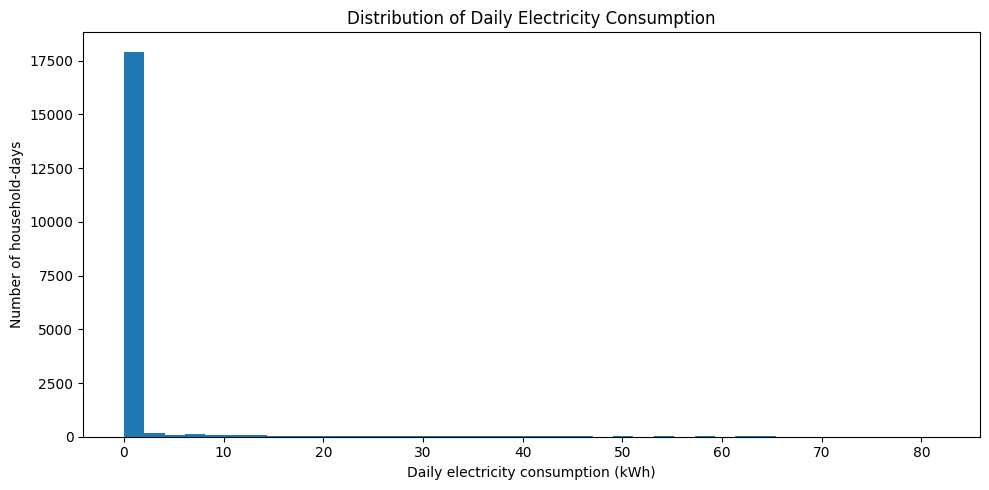

In [25]:
# 30. OPTIONAL EDA — TARGET DISTRIBUTION

plt.figure(figsize=(10, 5))
plt.hist(model_data[TARGET].dropna(), bins=40)
plt.xlabel("Daily electricity consumption (kWh)")
plt.ylabel("Number of household-days")
plt.title("Distribution of Daily Electricity Consumption")
plt.tight_layout()
plt.show()


In [26]:
# 31. CITY-WISE CONSUMPTION SUMMARY

city_summary = (
    model_data
    .groupby("city")
    .agg(
        houses=("house", "nunique"),
        days=("date", "nunique"),
        records=("electricity_kwh", "size"),
        average_daily_kwh=("electricity_kwh", "mean"),
        minimum_daily_kwh=("electricity_kwh", "min"),
        maximum_daily_kwh=("electricity_kwh", "max")
    )
    .reset_index()
)

display(city_summary)


,city,houses,days,records,average_daily_kwh,minimum_daily_kwh,maximum_daily_kwh
0,Islamabad,10,396,3150,0.475273,0.0,15.499792
1,Karachi,10,396,3332,1.761457,0.0,73.803239
2,Lahore,10,355,3195,1.485352,0.0,48.733018
3,Multan,10,384,3316,0.015839,0.0,0.134009
4,Peshawar,10,366,3191,0.013665,0.0,0.123810
5,Skardu,9,471,2997,4.705970,0.0,81.780713


In [27]:
# 32. CREATE FEATURE LIST FOR THE DECISION TREE NOTEBOOK

# Exclude identifiers and target from the predictor list.
exclude_from_features = {
    "electricity_kwh",
    "date"
}

feature_columns = [
    c for c in model_data.columns
    if c not in exclude_from_features
]

numeric_features = [
    c for c in feature_columns
    if pd.api.types.is_numeric_dtype(model_data[c])
]

categorical_features = [
    c for c in feature_columns
    if c not in numeric_features
]

feature_list = pd.DataFrame({
    "feature": numeric_features + categorical_features,
    "type": (
        ["numeric"] * len(numeric_features)
        + ["categorical"] * len(categorical_features)
    )
})

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

display(feature_list)


Numeric features: 74
Categorical features: 15


,feature,type
0,readings,numeric
1,avg_power_kw,numeric
2,max_power_kw,numeric
3,min_power_kw,numeric
4,expected_readings,numeric
5,coverage_pct,numeric
6,low_coverage_flag,numeric
7,no_of_people_temp_perm,numeric
8,no_of_permanent_residents,numeric
9,no_of_children_0_13,numeric


In [28]:
# 33. SAVE FINAL PRE-DECISION-TREE DATASET

final_file = PROCESSED_DIR / "powerplus_pre_decision_tree.csv"
feature_file = PROCESSED_DIR / "powerplus_feature_list_pre_model.csv"

model_data.to_csv(final_file, index=False)
feature_list.to_csv(feature_file, index=False)

print("FINAL PRE-DECISION-TREE FILE:")
print(final_file)

print("\nFEATURE LIST:")
print(feature_file)

print("\nFinal shape:", model_data.shape)


FINAL PRE-DECISION-TREE FILE:
d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_pre_decision_tree.csv

FEATURE LIST:
d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_feature_list_pre_model.csv

Final shape: (19181, 91)


In [29]:
# 34. FINAL DATA QUALITY CHECK

print("========== FINAL CHECK ==========")
print("Rows:", len(model_data))
print("Columns:", len(model_data.columns))
print("Cities:", model_data["city"].nunique())
print("Houses:", model_data["house"].nunique())
print("Date range:", model_data["date"].min(), "to", model_data["date"].max())
print("Target:", TARGET)
print("Target missing:", model_data[TARGET].isna().sum())

remaining_missing = model_data.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("\nRemaining missing values:")
display(remaining_missing.to_frame("count"))

print("\nFinal columns:")
print(model_data.columns.tolist())


========== FINAL CHECK ==========
Rows: 19181
Columns: 91
Cities: 6
Houses: 59
Date range: 2023-08-15 00:00:00 to 2024-11-27 00:00:00
Target: electricity_kwh
Target missing: 0

Remaining missing values:


,count



Final columns:
['city', 'house', 'date', 'electricity_kwh', 'readings', 'avg_power_kw', 'max_power_kw', 'min_power_kw', 'expected_readings', 'coverage_pct', 'low_coverage_flag', 'house_1', 'city_1', 'owner_rented', 'no_of_people_temp_perm', 'no_of_permanent_residents', 'no_of_children_0_13', 'no_of_adults_14_60', 'no_of_seniors_above_60', 'no_of_temporary_residents', 'property_area_marla', 'covered_area', 'no_of_floors', 'floor_of_residency', 'build_year_of_house', 'wapda_connection_type', 'average_ceiling_height_ft', 'ceiling_type', 'roof_type', 'flooring_type', 'interior_wall', 'exterior_wall', 'no_of_rooms', 'room_dimensions', 'kitchen', 'number_of_washrooms', 'number_of_stores', 'doors_type', 'air_conditioners', 'air_coolers', 'refrigerators', 'washing_machines', 'led_bulbs', 'tube_lights', 'celling_fans', 'wall_fans', 'stand_fans', 'water_dispensers', 'water_pumps', 'electric_cooker', 'electric_heaters', 'electric_irons', 'sewing_machine', 'microwave_ovens', 'geysers', 'ups', 'ot

# 35. MILESTONE STATUS

## Completed before this notebook

- [x] Import minute-level electricity
- [x] Convert electricity to daily kWh
- [x] Clean household metadata
- [x] Import historical weather CSVs
- [x] Convert weather to daily features
- [x] Merge electricity + metadata + weather
- [x] Calendar feature engineering
- [x] Lag features
- [x] Rolling historical-demand features

## Completed in this notebook

- [x] Standardize all column names
- [x] Standardize city names
- [x] Standardize house identifiers
- [x] EDA on every column
- [x] Calculate average/mean for every numerical column
- [x] Missing-value analysis
- [x] Mean imputation for appropriate numerical predictors
- [x] Categorical missing-value handling
- [x] Protect target from imputation
- [x] Protect structural lag/rolling missing values
- [x] Create final pre-Decision-Tree dataset
- [x] Create feature list

## NEXT MILESTONE — Decision Tree

- [ ] Time-based train/test split
- [ ] Fit preprocessing only on training data where required
- [ ] Encode categorical features
- [ ] Train Decision Tree Regressor
- [ ] Tune `max_depth`, `min_samples_split`, etc.
- [ ] Evaluate MAE
- [ ] Evaluate RMSE
- [ ] Evaluate R²
- [ ] Check feature importance
- [ ] Build 7-day forecasting logic
- [ ] Build 30-day forecasting logic
- [ ] Prepare future weather inputs for real future forecasts
- [ ] Build consumer input/interface
- [ ] Connect consumer appliance/household profile to prediction


# 36. OUTPUT FILES FROM THIS NOTEBOOK

After **Run All**, the `processed_data` folder should contain:

```text
processed_data/
│
├── powerplus_daily_merged.csv
│
├── powerplus_eda_numeric_summary.csv
├── powerplus_mean_imputation_report.csv
├── powerplus_categorical_imputation_report.csv
├── powerplus_missing_before_after.csv
│
├── powerplus_pre_decision_tree.csv
└── powerplus_feature_list_pre_model.csv
```

### Most important file for the next notebook

**`processed_data/powerplus_pre_decision_tree.csv`**

This is the file you will use for the **Decision Tree notebook**.


